# European Bird Sightings Analysis
## Combining and Analyzing eBird Data from 47 European Countries

This notebook will:
1. Combine all your CSV files into one dataset
2. Perform comprehensive statistical analysis
3. Create visualizations
4. Export results

---

## Setup and Imports

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from datetime import datetime

warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 1000)

print("✓ Libraries imported successfully!")

✓ Libraries imported successfully!


## 2. Data Preprocessing

In [2]:
combined_df = pd.read_csv("/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/ebird/migra_species_europe_only.csv")
combined_df.shape

(878189, 20)

In [3]:
# Load the bird species reference file
# UPDATE THIS PATH if your CSV file is in a different location
reference_file = '/Users/dazedinthecity/Documents/GitHub/ceu-ds-project-groupB-2026/datasets/bird_species_migration.csv'  # Change as needed

try:
    bird_reference = pd.read_csv(reference_file)
    print("✓ Bird species reference file loaded successfully!")
    print(f"\nReference file contains {len(bird_reference)} rows")
    print(f"\nColumns: {bird_reference.columns.tolist()}")
except FileNotFoundError:
    print(f"Error: Could not find '{reference_file}'")
    print("Please update the reference_file path in the cell above.")

✓ Bird species reference file loaded successfully!

Reference file contains 12 rows

Columns: ['bird_species', 'ebird_code', 'migration_period', 'migration_group']


In [4]:
migration_map = dict(zip(
    bird_reference['bird_species'].str.lower(),
    bird_reference['migration_period']
))

# Map migration groups to observations
combined_df['migration_group'] = combined_df['COMMON NAME'].str.lower().map(migration_map)


In [5]:
combined_df = combined_df[combined_df['migration_group']=='S']

In [6]:
combined_df

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group
48059,Sanderling,Calidris alba,1.0,NaN,Denmark,DK,StorstrÃ¸m,DK-04,Guldborgsund,DK-04-02,NaN,Birkemose,L7320548,H,54.567502,11.970531,2017-09-07,obsr1069066,S45480885,Banding,S
48060,Sanderling,Calidris alba,14.0,NaN,Spain,ES,Cantabria,ES-CB,NaN,NaN,NaN,Oyambre PNat--Ensenada de la Rabia y playa de ...,L3909140,H,43.393272,-4.333713,2017-05-04,obsr723159,S36554945,Incidental,S
48061,Sanderling,Calidris alba,27.0,NaN,Netherlands,NL,Zeeland,NL-ZE,NaN,NaN,NaN,Brouwersdam--Spuisluis,L5162839,H,51.748707,3.824714,2017-12-28,obsr995310,S41606734,Traveling,S
48062,Sanderling,Calidris alba,1.0,NaN,Iceland,IS,NorÃ°urland eystra,IS-6,NaN,NaN,NaN,BakkakrÃ³kur,L1121546,H,66.072347,-17.352476,2017-06-01,obsr247295,S37313407,Traveling,S
48063,Sanderling,Calidris alba,1.0,NaN,Portugal,PT,Porto,PT-13,Vila Nova de Gaia,PT-13-VG,NaN,RNL EstuÃ¡rio do Douro--Ã¡rea geral,L1826362,H,41.136738,-8.662477,2017-12-16,obsr1041985,S46167097,Historical,S
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
830736,Garganey,Spatula querquedula,1.0,NaN,Ukraine,UA,Chernihivs'ka Oblast',UA-74,NaN,NaN,NaN,ÐÐµÑÐµÐ¼Ð¸ÑÑÐºÐµ Ð§ÐµÑÐ½ÑÐ³ÑÐ²ÑÑÐºÐ° ...,L9637648,P,50.883452,30.832099,2019-07-14,obsr804075,S58161951,Traveling,S
830737,Garganey,Spatula querquedula,1.0,NaN,Ukraine,UA,Chernihivs'ka Oblast',UA-74,NaN,NaN,NaN,"Avtoshlyakh T 1008, Chernihivs'ka oblast, UA (...",L9648970,P,50.884108,30.869386,2019-07-14,obsr1129593,S58219196,Traveling,S
830738,Garganey,Spatula querquedula,15.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Unnamed Road, Ð Ð¾ÐºÐ¸ÑÐ½Ðµ, Ð§ÐµÑÐ½ÑÐ²ÐµÑ...",L14171926,P,48.335489,26.174703,2021-03-27,obsr1524677,S84171334,Traveling,S
830739,Garganey,Spatula querquedula,7.0,NaN,Ukraine,UA,Chernivets'ka Oblast',UA-77,NaN,NaN,NaN,"Ð§ÐµÑÐ½ÑÐ²ÑÑ OÐ±'ÑÐ·Ð½Ð°, Ð§ÐµÑÐ½ÑÐ²ÑÑ...",L11373073,P,48.278235,26.011840,2021-04-03,obsr1524677,S84655829,Traveling,S


In [7]:
combined_df.head()

,COMMON NAME,SCIENTIFIC NAME,OBSERVATION COUNT,AGE/SEX,COUNTRY,COUNTRY CODE,STATE,STATE CODE,COUNTY,COUNTY CODE,ATLAS BLOCK,LOCALITY,LOCALITY ID,LOCALITY TYPE,LATITUDE,LONGITUDE,OBSERVATION DATE,OBSERVER ID,SAMPLING EVENT IDENTIFIER,OBSERVATION TYPE,migration_group
48059,Sanderling,Calidris alba,1.0,NaN,Denmark,DK,StorstrÃ¸m,DK-04,Guldborgsund,DK-04-02,NaN,Birkemose,L7320548,H,54.567502,11.970531,2017-09-07,obsr1069066,S45480885,Banding,S
48060,Sanderling,Calidris alba,14.0,NaN,Spain,ES,Cantabria,ES-CB,NaN,NaN,NaN,Oyambre PNat--Ensenada de la Rabia y playa de ...,L3909140,H,43.393272,-4.333713,2017-05-04,obsr723159,S36554945,Incidental,S
48061,Sanderling,Calidris alba,27.0,NaN,Netherlands,NL,Zeeland,NL-ZE,NaN,NaN,NaN,Brouwersdam--Spuisluis,L5162839,H,51.748707,3.824714,2017-12-28,obsr995310,S41606734,Traveling,S
48062,Sanderling,Calidris alba,1.0,NaN,Iceland,IS,NorÃ°urland eystra,IS-6,NaN,NaN,NaN,BakkakrÃ³kur,L1121546,H,66.072347,-17.352476,2017-06-01,obsr247295,S37313407,Traveling,S
48063,Sanderling,Calidris alba,1.0,NaN,Portugal,PT,Porto,PT-13,Vila Nova de Gaia,PT-13-VG,NaN,RNL EstuÃ¡rio do Douro--Ã¡rea geral,L1826362,H,41.136738,-8.662477,2017-12-16,obsr1041985,S46167097,Historical,S


In [8]:
# Convert date column to datetime
combined_df['obsDt'] = pd.to_datetime(combined_df['OBSERVATION DATE'], errors='coerce')

# Extract temporal features
combined_df['year'] = combined_df['obsDt'].dt.year
combined_df['month'] = combined_df['obsDt'].dt.month
combined_df['day_of_week'] = combined_df['obsDt'].dt.dayofweek
combined_df['day_of_year'] = combined_df['obsDt'].dt.dayofyear

# drop 2026 (it ruins the results)
combined_df = combined_df[combined_df['year'] != 2026]

# Convert count to numeric
combined_df['howMany'] = pd.to_numeric(combined_df['OBSERVATION COUNT'], errors='coerce')

print("✓ Data preprocessing complete!")
print(f"\nDate range: {combined_df['obsDt'].min()} to {combined_df['obsDt'].max()}")
print(f"Years covered: {sorted(combined_df['year'].dropna().unique().astype(int).tolist())}")

✓ Data preprocessing complete!

Date range: 2017-01-01 00:00:00 to 2022-12-31 00:00:00
Years covered: [2017, 2018, 2019, 2020, 2021, 2022]


## 3. Basic Statistics

In [9]:
# Overall statistics
print("="*80)
print("OVERALL DATASET STATISTICS")
print("="*80)
print(f"\nTotal observations: {len(combined_df):,}")
print(f"Number of countries: {combined_df['COUNTRY CODE'].nunique()}")
print(f"Number of states/regions: {combined_df['STATE CODE'].nunique()}")
print(f"Number of counties: {combined_df['COUNTY CODE'].nunique()}")
print(f"Number of unique species: {combined_df['SCIENTIFIC NAME'].nunique()}")
print(f"Number of locality types: {combined_df['LOCALITY TYPE'].nunique()}")
print(f"Number of observation types: {combined_df['OBSERVATION TYPE'].nunique()}")
print(f"Number of unique observers: {combined_df['OBSERVER ID'].nunique()}")

# Count data statistics
count_data = combined_df[combined_df['howMany'].notna()]
print(f"\nObservations with count data: {len(count_data):,} ({len(count_data)/len(combined_df)*100:.1f}%)")
if len(count_data) > 0:
    print(f"Total birds counted: {count_data['howMany'].sum():,.0f}")
    print(f"Average count per observation: {count_data['howMany'].mean():.2f}")
    print(f"Median count: {count_data['howMany'].median():.0f}")
    print(f"Maximum count in single observation: {count_data['howMany'].max():,.0f}")
    print(f"Minimum count: {count_data['howMany'].min():.0f}")

OVERALL DATASET STATISTICS

Total observations: 370,831
Number of countries: 44
Number of states/regions: 579
Number of counties: 822
Number of unique species: 5
Number of locality types: 2
Number of observation types: 8
Number of unique observers: 16272

Observations with count data: 370,831 (100.0%)
Total birds counted: 13,473,827
Average count per observation: 36.33
Median count: 2
Maximum count in single observation: 140,000
Minimum count: 1


### outlier removal for col 'howMany'

In [10]:
Q1 = combined_df['howMany'].quantile(0.25)
Q3 = combined_df['howMany'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = combined_df[(combined_df['howMany'] < lower_bound) | (combined_df['howMany'] > upper_bound)]

print("="*80)
print("OUTLIER ANALYSIS: howMany")
print("="*80)
print(f"\nQ1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower bound: {lower_bound}")
print(f"Upper bound: {upper_bound}")
print(f"\nTotal outliers: {len(outliers):,} ({len(outliers)/len(combined_df)*100:.2f}% of data)")
print(f"\nOutlier summary:")
print(outliers['howMany'].describe())

OUTLIER ANALYSIS: howMany

Q1: 1.0
Q3: 8.0
IQR: 7.0
Lower bound: -9.5
Upper bound: 18.5

Total outliers: 52,079 (14.04% of data)

Outlier summary:
count     52079.000000
mean        236.552008
std        2684.706487
min          19.000000
25%          25.000000
50%          40.000000
75%          75.000000
max      140000.000000
Name: howMany, dtype: float64


In [11]:
print("="*80)
print("OUTLIER DISTRIBUTION: howMany")
print("="*80)

# Value counts for outliers
outlier_dist = outliers['howMany'].value_counts().sort_index()

print(f"\nTop 20 most frequent outlier values:")
print(outliers['howMany'].value_counts().head(20))

print(f"\nOutlier range distribution (binned):")
bins = [lower_bound, 50, 100, 500, 1000, 5000, float('inf')]
labels = [f'{int(lower_bound)}-50', '51-100', '101-500', '501-1000', '1001-5000', '5000+']
outlier_binned = pd.cut(outliers['howMany'], bins=bins, labels=labels)
print(outlier_binned.value_counts().sort_index())

print(f"\nKey outlier statistics:")
print(f"  Min outlier value:    {outliers['howMany'].min():,.0f}")
print(f"  Max outlier value:    {outliers['howMany'].max():,.0f}")
print(f"  Mean outlier value:   {outliers['howMany'].mean():,.2f}")
print(f"  Median outlier value: {outliers['howMany'].median():,.0f}")

OUTLIER DISTRIBUTION: howMany

Top 20 most frequent outlier values:
howMany
20.0     6874
30.0     4646
50.0     3249
25.0     2951
40.0     2690
100.0    1838
60.0     1494
35.0     1279
22.0     1050
200.0     988
80.0      988
19.0      986
23.0      894
21.0      856
24.0      812
150.0     800
26.0      789
70.0      769
45.0      759
28.0      674
Name: count, dtype: int64

Outlier range distribution (binned):
howMany
-9-50        33865
51-100        9503
101-500       7054
501-1000       722
1001-5000      681
5000+          254
Name: count, dtype: int64

Key outlier statistics:
  Min outlier value:    19
  Max outlier value:    140,000
  Mean outlier value:   236.55
  Median outlier value: 40


In [12]:
high_outliers = outliers[outliers['howMany'] > 100]

print("="*80)
print("LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100")
print("="*80)
print(f"\nTotal rows with howMany > 100: {len(high_outliers):,}")
print(f"\nLocality Type Distribution:")
print(high_outliers['LOCALITY TYPE'].value_counts())
print(f"\nLocality Type Proportions:")
print(high_outliers['LOCALITY TYPE'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

LOCALITY TYPES FOR OUTLIERS WHERE howMany > 100

Total rows with howMany > 100: 8,711

Locality Type Distribution:
LOCALITY TYPE
H    7079
P    1632
Name: count, dtype: int64

Locality Type Proportions:
LOCALITY TYPE
H    81.27%
P    18.73%
Name: proportion, dtype: object


#### dropping outliers

In [13]:
before = len(combined_df)
combined_df = combined_df[combined_df['howMany'] <= 100]
after = len(combined_df)

print("="*80)
print("AFTER DROPPING howMany > 100")
print("="*80)
print(f"\nRows before: {before:,}")
print(f"Rows after:  {after:,}")
print(f"Rows dropped: {before - after:,} ({(before - after)/before*100:.2f}% of data)")

AFTER DROPPING howMany > 100

Rows before: 370,831
Rows after:  362,120
Rows dropped: 8,711 (2.35% of data)


## 4. Analysis by Country

In [14]:
print(combined_df['STATE'].isna().sum(),combined_df['COUNTY'].isna().sum())

0 128811


In [15]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted']

country_stats = country_stats.sort_values('Total Observations', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted
          ES                  Spain               82718               5             18               48             613784.0
          GB         United Kingdom               74112               5              4              100             538021.0
          PT               Portugal               36790               5             20              146             358062.0
          DE                Germany               18870               5             16              273             130075.0
          PL                 Poland               15640               5             16                0             153394.0
          SE                 Sweden               13223               5             21                0              83690.0
          FI                Finland               12792               5             19                

In [16]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

country_stats = country_stats.sort_values('Unique Observers', ascending=False)

print("\nSTATISTICS BY COUNTRY")
print("="*120)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers
          ES                  Spain               82718               5             18               48             613784.0              4787
          GB         United Kingdom               74112               5              4              100             538021.0              4154
          PT               Portugal               36790               5             20              146             358062.0              2089
          FR                 France               12364               5             13               89              97866.0              1256
          DE                Germany               18870               5             16              273             130075.0              1122
          NL            Netherlands                9123               5             12                2              71

### relative to number of observers

In [17]:
country_stats = combined_df.groupby(['COUNTRY CODE', 'COUNTRY']).agg(
    total_observations=('SAMPLING EVENT IDENTIFIER', 'count'),
    unique_species=('SCIENTIFIC NAME', 'nunique'),
    unique_states=('STATE', 'nunique'),
    unique_counties=('COUNTY', 'nunique'),
    total_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0),
    unique_observers=('OBSERVER ID', 'nunique')
).reset_index()

country_stats.columns = ['Country Code', 'Country Name', 'Total Observations', 
                         'Unique Species', 'Unique States', 'Unique Counties', 
                         'Total Birds Counted', 'Unique Observers']

# Calculate per-observer metrics
country_stats['Obs per Observer']      = (country_stats['Total Observations'] / country_stats['Unique Observers']).round(1)
# country_stats['Species per Observer']  = (country_stats['Unique Species']      / country_stats['Unique Observers']).round(1)
# country_stats['Birds per Observer']    = (country_stats['Total Birds Counted'] / country_stats['Unique Observers']).round(1)
# country_stats['Counties per Observer'] = (country_stats['Unique Counties']     / country_stats['Unique Observers']).round(2)

country_stats = country_stats.sort_values('Obs per Observer', ascending=False)

print("\nSTATISTICS BY COUNTRY (relative to unique observers)")
print("="*150)
print(country_stats.to_string(index=False))


STATISTICS BY COUNTRY (relative to unique observers)
Country Code           Country Name  Total Observations  Unique Species  Unique States  Unique Counties  Total Birds Counted  Unique Observers  Obs per Observer
          MD                Moldova                1112               4             29                0              15901.0                24              46.3
          CZ         Czech Republic               11100               5             14                0              85672.0               327              33.9
          PL                 Poland               15640               5             16                0             153394.0               548              28.5
          RS                 Serbia                3088               5             17                0              34514.0               115              26.9
          FI                Finland               12792               5             19                0              98462.0               55

### year and locality type

In [ ]:
yearly_obs = combined_df.groupby('year').size().sort_index()

print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")
        locality_counts = (
            combined_df[combined_df['year'] == year]
            .groupby('LOCALITY TYPE')
            .size()
            .sort_values(ascending=False)
        )
        for locality, loc_count in locality_counts.items():
            print(f"    {locality}: {loc_count:,}")

        h = locality_counts.get('H', 0)
        p = locality_counts.get('P', 0)
        diff = h - p
        sign = "+" if diff > 0 else ""
        print(f"    H - P = {sign}{diff:,}")

## 5. Species Analysis

In [18]:
# Species statistics
species_stats = combined_df.groupby(['COMMON NAME', 'SCIENTIFIC NAME']).agg({
    'SAMPLING EVENT IDENTIFIER': 'count',
    'COUNTRY CODE': 'nunique',
    'STATE CODE': 'nunique',
    'howMany': lambda x: x.sum() if x.notna().any() else 0
}).reset_index()

species_stats.columns = ['Common Name', 'Scientific Name', 
                        'Total Observations', 'Countries Found', 'States Found', 'Total Count']

species_stats = species_stats.sort_values('Total Observations', ascending=False)

print("\nTOP 30 MOST OBSERVED SPECIES")
print("="*120)
print(species_stats.head(30).to_string(index=False))


TOP 30 MOST OBSERVED SPECIES
   Common Name     Scientific Name  Total Observations  Countries Found  States Found  Total Count
          Ruff     Calidris pugnax              109964               42           491     951843.0
    Sanderling       Calidris alba               85484               42           305     984336.0
Wood Sandpiper     Tringa glareola               74871               42           523     418857.0
      Garganey Spatula querquedula               52675               43           511     233464.0
      Red Knot    Calidris canutus               39126               40           273     316233.0


## 6. Temporal Analysis


TEMPORAL ANALYSIS

Observations by Year:
  2017: 32,480
  2018: 37,929
  2019: 49,827
  2020: 54,004
  2021: 79,427
  2022: 108,453

Observations by month of 2017
  January: 1,507
  February: 936
  March: 2,274
  April: 5,148
  May: 4,519
  June: 1,298
  July: 2,114
  August: 4,200
  September: 4,985
  October: 2,685
  November: 1,339
  December: 1,475
  → Peak migration month: April (5,148 observations)

Observations by month of 2018
  January: 1,795
  February: 1,416
  March: 2,625
  April: 5,405
  May: 6,156
  June: 1,715
  July: 3,004
  August: 5,258
  September: 5,197
  October: 2,450
  November: 1,341
  December: 1,567
  → Peak migration month: May (6,156 observations)

Observations by month of 2019
  January: 2,053
  February: 1,594
  March: 3,827
  April: 7,805
  May: 7,575
  June: 1,808
  July: 3,690
  August: 7,206
  September: 6,931
  October: 3,274
  November: 1,964
  December: 2,100
  → Peak migration month: April (7,805 observations)

Observations by month of 2020
  Janu

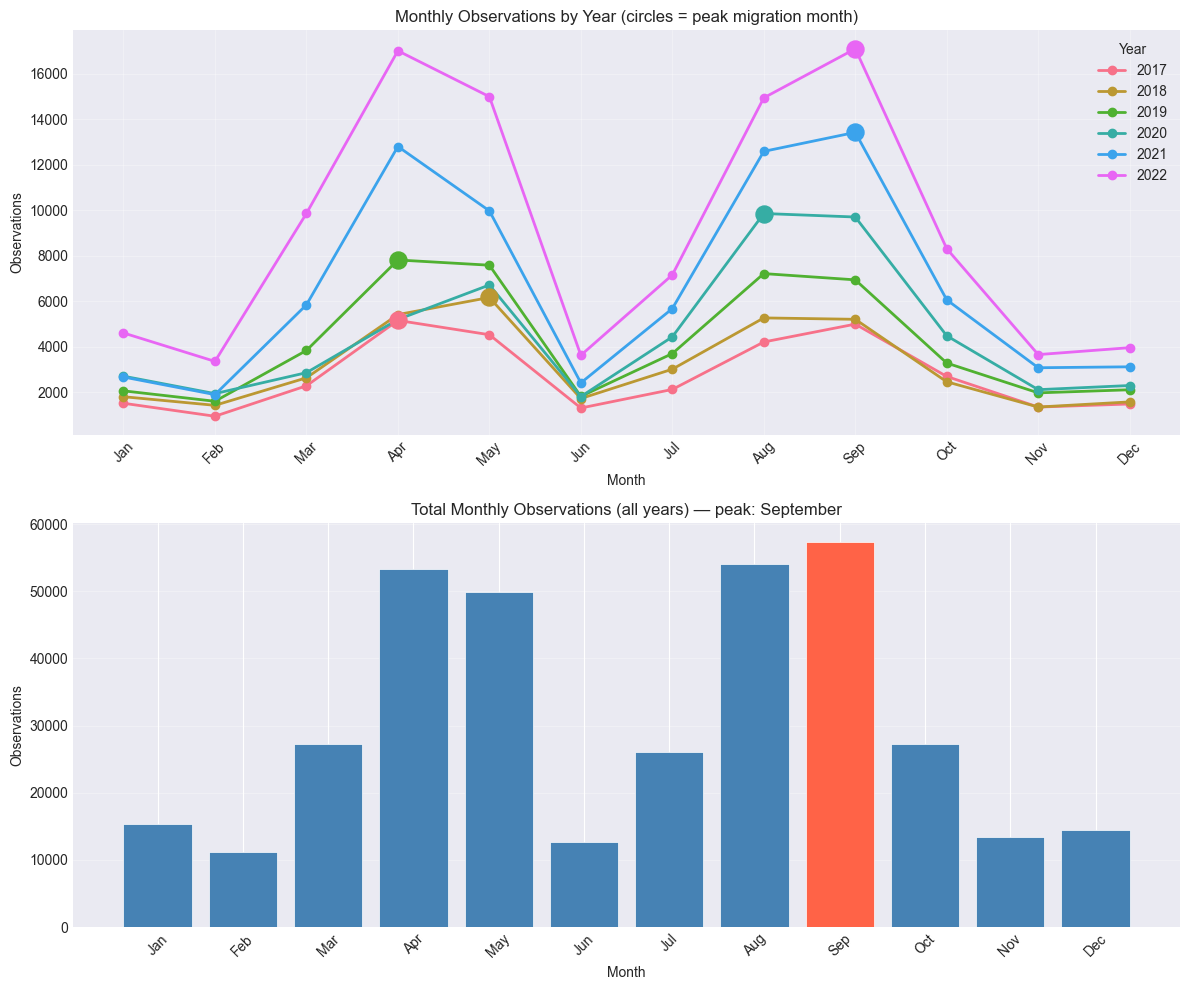

In [19]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').size().sort_index()
print("\nObservations by Year:")
for year, count in yearly_obs.items():
    if pd.notna(year):
        print(f"  {int(year)}: {count:,}")

# Month each year
month_names = {1: 'January', 2: 'February', 3: 'March', 4: 'April', 5: 'May', 6: 'June',
               7: 'July', 8: 'August', 9: 'September', 10: 'October', 11: 'November', 12: 'December'}

peak_months_by_year = {}  # store peak month per year

yearly_obs = combined_df.groupby('year').size().sort_index()
for year in yearly_obs.index:
    print("\nObservations by month of", int(year))
    monthly_obs = combined_df[combined_df['year'] == year].groupby('month').size().sort_index()
    for month, count in monthly_obs.items():
        if pd.notna(month):
            print(f"  {month_names[int(month)]}: {count:,}")
    
    # Save peak month for this year
    peak_month = monthly_obs.idxmax()
    if pd.notna(peak_month):
        peak_months_by_year[int(year)] = {
            'month': int(peak_month),
            'month_name': month_names[int(peak_month)],
            'count': monthly_obs.max()
        }
        print(f"  → Peak migration month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# By month (all years combined)
monthly_obs = combined_df.groupby('month').size().sort_index()
print("\nObservations by Month (all years):")
for month, count in monthly_obs.items():
    if pd.notna(month):
        print(f"  {month_names[int(month)]}: {count:,}")

# Peak observation period
peak_month = monthly_obs.idxmax()
if pd.notna(peak_month):
    print(f"\nPeak observation month: {month_names[int(peak_month)]} ({monthly_obs.max():,} observations)")

# Print summary of peak months
print("\nPeak Migration Month by Year:")
for year, info in peak_months_by_year.items():
    print(f"  {year}: {info['month_name']} ({info['count']:,} observations)")

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Monthly observations per year (lines)
ax1 = axes[0]
for year in yearly_obs.index:
    if pd.notna(year):
        monthly = combined_df[combined_df['year'] == year].groupby('month').size().reindex(range(1, 13), fill_value=0)
        ax1.plot(range(1, 13), monthly.values, marker='o', label=str(int(year)), linewidth=2)
        # Mark peak month
        if int(year) in peak_months_by_year:
            pm = peak_months_by_year[int(year)]['month']
            ax1.scatter(pm, monthly[pm], s=150, zorder=5)

ax1.set_xticks(range(1, 13))
ax1.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax1.set_title('Monthly Observations by Year (circles = peak migration month)')
ax1.set_xlabel('Month')
ax1.set_ylabel('Observations')
ax1.legend(title='Year')
ax1.grid(True, alpha=0.3)

# Plot 2: Combined monthly observations (bar)
ax2 = axes[1]
colors = ['tomato' if m == int(peak_month) else 'steelblue' for m in range(1, 13)]
monthly_all = combined_df.groupby('month').size().reindex(range(1, 13), fill_value=0)
bars = ax2.bar(range(1, 13), monthly_all.values, color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xticks(range(1, 13))
ax2.set_xticklabels([month_names[m][:3] for m in range(1, 13)], rotation=45)
ax2.set_title(f'Total Monthly Observations (all years) — peak: {month_names[int(peak_month)]}')
ax2.set_xlabel('Month')
ax2.set_ylabel('Observations')
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
#plt.savefig('temporal_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
#print("\nPlot saved as 'temporal_analysis.png'")

In [20]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        print(f"  {int(year)}: {row['observations']:,} observations | {row['number_of_birds']:,} number of birds counted")
        #print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
  2017: 32,480.0 observations | 253,281.0 number of birds counted
  2018: 37,929.0 observations | 301,634.0 number of birds counted
  2019: 49,827.0 observations | 395,523.0 number of birds counted
  2020: 54,004.0 observations | 461,068.0 number of birds counted
  2021: 79,427.0 observations | 648,492.0 number of birds counted
  2022: 108,453.0 observations | 844,735.0 number of birds counted


In [21]:
# Temporal distribution
print("\nTEMPORAL ANALYSIS")
print("="*60)

# By year
yearly_obs = combined_df.groupby('year').agg(
    observations=('OBSERVER ID', 'count'),
    unique_observers=('OBSERVER ID', 'nunique'),
    number_of_birds=('howMany', lambda x: x.sum() if x.notna().any() else 0)
).sort_index()

print("\nObservations by Year:")
for year, row in yearly_obs.iterrows():
    if pd.notna(year):
        # print(f"  {int(year)}: {row['number_of_birds']:,} number of birds counted | {row['unique_observers']:,} unique observers")
        print(f"    Avg bird per observer: {(row['number_of_birds'] / row['unique_observers']):.2f}")
        # print(f"  {int(year)}: {row['observations']:,} observations | {row['unique_observers']:,} unique observers")
        print(f"    Avg obs per observer: {(row['observations'] / row['unique_observers']):.2f}")




TEMPORAL ANALYSIS

Observations by Year:
    Avg bird per observer: 72.30
    Avg obs per observer: 9.27
    Avg bird per observer: 69.89
    Avg obs per observer: 8.79
    Avg bird per observer: 75.12
    Avg obs per observer: 9.46
    Avg bird per observer: 91.79
    Avg obs per observer: 10.75
    Avg bird per observer: 92.75
    Avg obs per observer: 11.36
    Avg bird per observer: 87.86
    Avg obs per observer: 11.28


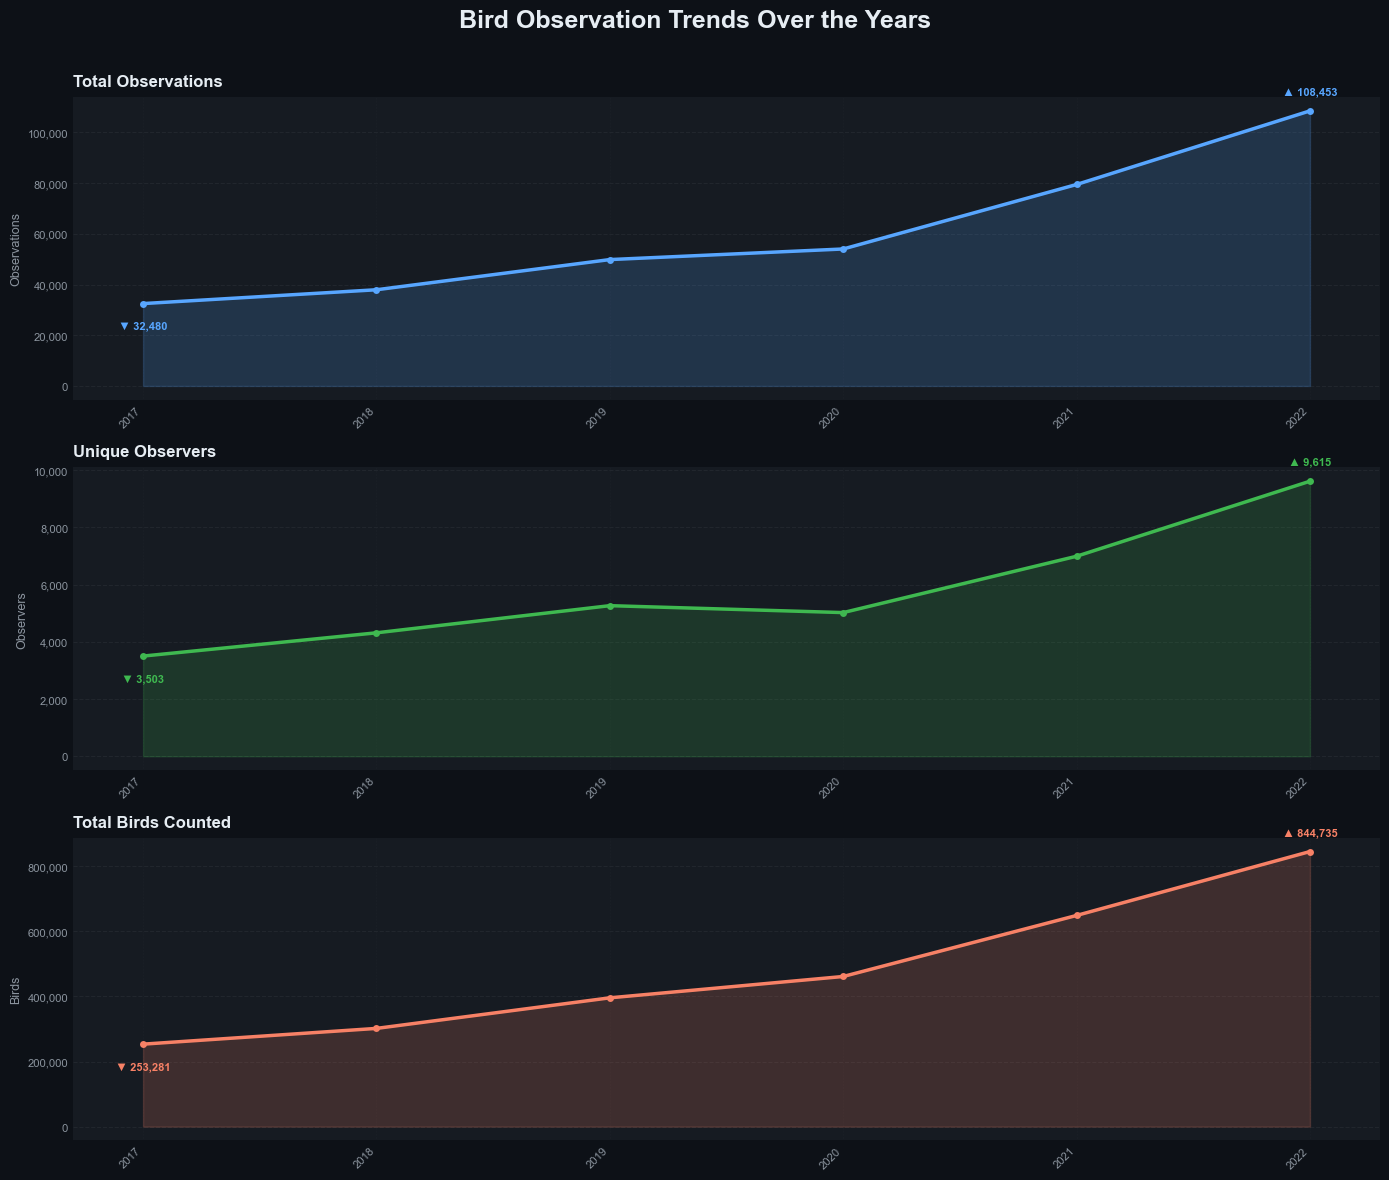

Plot saved to yearly_trends.png


In [22]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), facecolor='#0d1117')
fig.suptitle('Bird Observation Trends Over the Years', 
             fontsize=18, fontweight='bold', color='#e6edf3', y=0.98)

years = yearly_obs.index.astype(int)

metrics = [
    ('observations',     '#58a6ff', 'Total Observations',     'Observations'),
    ('unique_observers', '#3fb950', 'Unique Observers',        'Observers'),
    ('number_of_birds',  '#f78166', 'Total Birds Counted',     'Birds'),
]

for ax, (col, color, title, ylabel) in zip(axes, metrics):
    values = yearly_obs[col].values

    ax.set_facecolor('#161b22')
    ax.fill_between(years, values, alpha=0.18, color=color)
    ax.plot(years, values, color=color, linewidth=2.5, marker='o',
            markersize=5, markerfacecolor=color, markeredgewidth=0)

    # Annotate min/max
    max_idx, min_idx = values.argmax(), values.argmin()
    for idx, label in [(max_idx, f'▲ {values[max_idx]:,.0f}'), 
                       (min_idx, f'▼ {values[min_idx]:,.0f}')]:
        ax.annotate(label, xy=(years[idx], values[idx]),
                    xytext=(0, 12 if idx == max_idx else -18),
                    textcoords='offset points', ha='center',
                    fontsize=8, color=color, fontweight='bold')

    ax.set_title(title, fontsize=12, color='#e6edf3', pad=8, loc='left', fontweight='bold')
    ax.set_ylabel(ylabel, color='#8b949e', fontsize=9)
    ax.tick_params(colors='#8b949e', labelsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
    ax.set_xlim(years[0] - 0.3, years[-1] + 0.3)
    ax.set_xticks(years)
    ax.set_xticklabels([str(y) for y in years], rotation=45, ha='right')
    for spine in ax.spines.values():
        spine.set_edgecolor('#30363d')
    ax.grid(axis='y', color='#21262d', linewidth=0.8, linestyle='--')
    ax.grid(axis='x', color='#21262d', linewidth=0.4, linestyle=':')

plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig('yearly_trends.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print("Plot saved to yearly_trends.png")

### 8.3 Migration Pattern Analysis by Season

Analyzing bird sightings based on migration groups across different seasonal periods:
- **Spring Migration Period**: Mid-March to Mid-June
- **Summer Period**: July to Early August
- **Autumn Migration Period**: Late August to Early December  
- **Winter Period**: Late December to Early March

In [23]:
# Define seasonal periods
def get_season(date):
    """
    Classify observation date into seasonal periods.
    """
    if pd.isna(date):
        return 'Unknown'
    
    month = date.month
    day = date.day
    
    # Spring Migration: Mid-March (Mar 15) to Mid-June (Jun 15)
    if (month == 3 and day >= 15) or (month in [4, 5]) or (month == 6 and day <= 15):
        return 'Spring Migration (Mid-Mar to Mid-Jun)'
    
    # Summer: July and Early August (to Aug 20)
    elif month == 7 or (month == 8 and day <= 20):
        return 'Summer (Jul to Early Aug)'
    
    # Autumn Migration: Late August (Aug 21) to Early December (Dec 10)
    elif (month == 8 and day > 20) or (month in [9, 10, 11]) or (month == 12 and day <= 10):
        return 'Autumn Migration (Late Aug to Early Dec)'
    
    # Winter: Late December (Dec 11+) to Early March (Mar 14)
    else:  # (month == 12 and day > 10) or (month in [1, 2]) or (month == 3 and day < 15)
        return 'Winter (Late Dec to Early Mar)'

# Apply seasonal classification
combined_df['season'] = combined_df['obsDt'].apply(get_season)

print("Observations by season:")
season_counts = combined_df['season'].value_counts()
for season, count in season_counts.items():
    print(f"  {season}: {count:,} observations")

Observations by season:
  Spring Migration (Mid-Mar to Mid-Jun): 129,957 observations
  Autumn Migration (Late Aug to Early Dec): 125,376 observations
  Summer (Jul to Early Aug): 57,514 observations
  Winter (Late Dec to Early Mar): 49,273 observations
